# Steam Sales Prediction — CIS 5450 Final Project Report

**Course**: CIS 5450 — Big Data Analytics  

**Team**: Jiantang Ma, Jun Yu Chen, Rita Wang, Ziyan Li 

**Date**: April 2026

---

## Project Overview

This notebook presents the complete end-to-end analysis for predicting estimated Steam game sales (`copiesSold`) using metadata available at or after a game's launch. The project spans five phases: exploratory data analysis, preprocessing, regression modelling, and simulation-based hypothesis testing.

**Dataset**: `games_merged.csv` — a left-joined merge of two sources:
- **Kaggle Steam dataset** (~115,000 game listings, metadata, pricing, review counts)  
- **Gamalytic dataset** (sales estimates, publisher classification, review scores)

**Target variable**: `copiesSold` (Gamalytic estimate) — modelled on the `log1p` scale due to extreme right-skew (skewness ≈ 70).

**Two modelling framings**:
- *Post-release*: all features including playtime and review counts (explanatory, not predictive at launch)
- *Launch-time*: only features observable at or before release (predictive framing used in the model comparison section)

---

## Table of Contents
1. [Data Description and Raw Data Preview](#1-data-description)
2. [Exploratory Data Analysis (EDA)](#2-eda)
3. [Preprocessing](#3-preprocessing)
4. [Modelling](#4-modelling)
5. [Hypothesis Testing](#5-hypothesis-testing)
6. [Conclusion and Next Steps](#6-conclusion)


## 0. Setup

In [47]:
import sys
from pathlib import Path

# Add project root to sys.path so all src modules are importable
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from configs.config import (
    RAW_MERGED_PATH, OUTPUT_DIR,
    TARGET_LOG, TARGET_RAW,
)
from src.data.loader import load_merged, validate_merged
from src.data.preprocessor import (
    run_preprocessing_pipeline,
    audit_columns,
    PUBLISHER_CLASS_ORDER,
)
from src.features.engineer import prepare_features, get_feature_columns
from src.models.baseline import (
    run_all_baselines,
    lasso_feature_importance,
    make_lasso,
    make_linear_regression,
    make_ridge,
    ols_summary,
)
from src.evaluation.metrics import evaluate_predictions

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:,.3f}".format)

print("Setup complete.")
print(f"Project root: {Path('..').resolve()}")

Setup complete.
Project root: /Users/arjianma/CIS5450-FINAL-PROJECT


---
<a id="1-data-description"></a>
## 1. Data Description and Raw Data Preview

The primary working file `games_merged.csv` is a **left join** of the Kaggle Steam dataset (AppID) onto the Gamalytic dataset (steamId), producing a 115,289-row file with 47 columns. Almost every Kaggle game matched a Gamalytic record — only 9 rows have a null target after merging.


In [48]:
df_raw = load_merged(RAW_MERGED_PATH, verbose=True)
print(f"\nRaw dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")


  games_merged.csv
  Rows: 115,289   Columns: 47

  Columns with >10% nulls:
    Movies                              100.0%
    Score rank                          100.0%
    Metacritic url                      96.4%
    Reviews                             89.6%
    Notes                               79.9%
    Website                             57.6%
    Support url                         53.5%
    Tags                                29.8%
    Support email                       12.0%


Raw dataset shape: 115,289 rows × 47 columns


### 1.1 Column dtypes and sample values

In [49]:
# Show dtypes and a representative row
print(df_raw.dtypes.to_string())

AppID                           int64
Name                           object
copiesSold                    float64
Release date                   object
Estimated owners               object
Peak CCU                        int64
Required age                    int64
Price                         float64
Discount                        int64
DLC count                       int64
About the game                 object
Supported languages            object
Full audio languages           object
Reviews                        object
Header image                   object
Website                        object
Support url                    object
Support email                  object
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                 object
User score                      int64
Positive                        int64
Negative                        int64
Score rank  

In [50]:
# Preview first 3 rows (wide format)
pd.set_option("display.max_columns", None)
df_raw.head(3)

,AppID,Name,copiesSold,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies,unreleased,firstReleaseDate,earlyAccess,reviewScore,publisherClass,steamUrl
0,1635980,Kubinashi Recollection,"2,637.000","Dec 8, 2021",0 - 20000,0,0,11.990,0,1,"In order to retrieve the lost memories, Sekiba...","['Simplified Chinese', 'Japanese', 'English']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,https://phoenixx.ne.jp/contactus/,support@phoenixx.ne.jp,True,False,False,0,NaN,0,163,8,NaN,40,158,NaN,0,0,0,0,給食頭蛮,Phoenixx Inc.,"Single-player,Steam Achievements,Steam Trading...","Action,Indie","Action,Puzzle,Faith,Cute,Pixel Graphics,Fantas...",https://shared.akamai.steamstatic.com/store_it...,NaN,False,2021-12-08T05:00:00.000Z,False,95.000,Indie,https://store.steampowered.com/app/1635980
1,3337970,Coffee Beans,36.000,"Nov 22, 2024",0 - 20000,0,0,0.690,0,0,Coffee Beans A fun and challenging Match 3 Typ...,['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://store.steampowered.com/search/?publishe...,http://store.steampowered.com/search/?publishe...,archor@archor.com,True,False,False,0,NaN,0,1,1,NaN,0,0,NaN,0,0,0,0,Archor Wright,Archor Games,"Single-player,Family Sharing","Casual,Indie","Casual,Puzzle,Clicker,2D,Capitalism,Physics,In...",https://shared.akamai.steamstatic.com/store_it...,NaN,False,2024-11-22T00:00:00.000Z,False,50.000,Indie,https://store.steampowered.com/app/3337970
2,1470270,Powerboat VR,741.000,"Dec 29, 2020",0 - 20000,0,0,18.990,0,0,Please note that this is an EARLY ACCESS game ...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,http://www.jimmyarcade.co.uk,NaN,support@jimmyarcade.co.uk,True,False,False,0,NaN,0,16,6,NaN,0,0,NaN,0,0,0,0,Jimmy Arcade Limited,Jimmy Arcade Limited,"Single-player,Tracked Controller Support,VR Su...","Indie,Simulation,Early Access","Exploration,Driving,Naval,Transportation,Manag...",https://shared.akamai.steamstatic.com/store_it...,NaN,False,2020-12-29T05:00:00.000Z,True,74.000,Indie,https://store.steampowered.com/app/1470270


### 1.2 Missing values

In [51]:
null_pct = df_raw.isnull().mean().mul(100).sort_values(ascending=False)
null_df = null_pct[null_pct > 0].reset_index()
null_df.columns = ["Column", "Null %"]
null_df["Null %"] = null_df["Null %"].map("{:.2f}%".format)
print(null_df.to_string(index=False))

          Column  Null %
          Movies 100.00%
      Score rank  99.97%
  Metacritic url  96.43%
         Reviews  89.56%
           Notes  79.87%
         Website  57.56%
     Support url  53.52%
            Tags  29.76%
   Support email  11.97%
      Publishers   0.53%
  About the game   0.16%
      Developers   0.15%
          Genres   0.10%
      unreleased   0.09%
firstReleaseDate   0.09%
     earlyAccess   0.09%
     reviewScore   0.09%
  publisherClass   0.09%
      copiesSold   0.09%
        steamUrl   0.09%
    Header image   0.05%
     Screenshots   0.05%
      Categories   0.01%
            Name   0.00%


### 1.3 Duplicates

In [52]:
n_dupes = df_raw.duplicated(subset="AppID").sum()
print(f"Duplicate AppIDs: {n_dupes}")
print(f"Total rows:       {len(df_raw):,}")

Duplicate AppIDs: 0
Total rows:       115,289


### 1.4 Feature overview

In [53]:
overview = pd.DataFrame({
    "Column": df_raw.columns,
    "dtype": df_raw.dtypes.values,
    "non_null": df_raw.notna().sum().values,
    "nunique": df_raw.nunique().values,
})
print(overview.to_string(index=False))

                    Column   dtype  non_null  nunique
                     AppID   int64    115289   115289
                      Name  object    115288   114260
                copiesSold float64    115191    25832
              Release date  object    115289     5115
          Estimated owners  object    115289       14
                  Peak CCU   int64    115289     1076
              Required age   int64    115289       15
                     Price float64    115289      651
                  Discount   int64    115289       85
                 DLC count   int64    115289      108
            About the game  object    115101   114602
       Supported languages  object    115289    19565
      Full audio languages  object    115289     3742
                   Reviews  object     12036    11882
              Header image  object    115226   115226
                   Website  object     48923    39073
               Support url  object     53586    35058
             Support email  

### 1.5 Feature groups summary

| Group | Key columns | Notes |
|---|---|---|
| **Target** | `copiesSold` | Gamalytic sales estimate; skewness ≈ 70 |
| **Price** | `Price` | USD; 14.6 % of games are free (Price = 0) |
| **Publisher** | `publisherClass` | Hobbyist / Indie / AA / AAA |
| **Reviews** | `Positive`, `Negative`, `reviewScore`, `Recommendations` | Post-release signals |
| **Content tags** | `Genres`, `Categories`, `Tags` | Comma-separated strings → binary columns in preprocessing |
| **Dates** | `Release date`, `firstReleaseDate` | Parsed to year / month / quarter |
| **Languages** | `Supported languages` | List string → `language_count` integer |
| **Ownership estimate** | `Estimated owners` | Range string → midpoint; post-release leakage risk |
| **Platform** | `Windows`, `Mac`, `Linux` | Boolean flags |
| **Near-entirely null** | `Movies`, `Score rank`, `Reviews`, `Notes`, `User score` | Dropped in preprocessing |


---
<a id="2-eda"></a>
## 2. Exploratory Data Analysis (EDA)


### 2.1 Target variable: `copiesSold`

In [54]:
# Summary statistics
print("copiesSold — descriptive statistics:")
print(df_raw["copiesSold"].describe().to_string())
print(f"\nSkewness: {df_raw['copiesSold'].skew():.1f}")

pcts = [50, 75, 90, 95, 99, 99.5]
print("\nPercentile breakdown:")
for p in pcts:
    val = df_raw["copiesSold"].quantile(p / 100)
    print(f"  {p:5.1f}th: {val:>15,.0f} copies")

copiesSold — descriptive statistics:
count       115,191.000
mean         70,582.205
std       1,549,270.460
min               0.000
25%              84.000
50%             601.000
75%           4,021.000
max     343,456,914.000

Skewness: 138.1

Percentile breakdown:
   50.0th:             601 copies
   75.0th:           4,021 copies
   90.0th:          29,187 copies
   95.0th:         101,890 copies
   99.0th:       1,096,246 copies
   99.5th:       2,384,454 copies


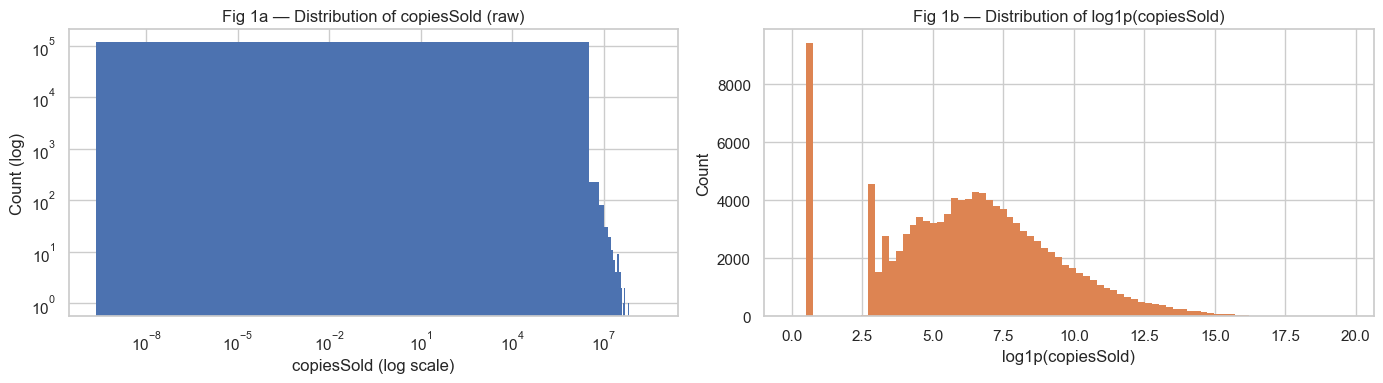

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw["copiesSold"].dropna(), bins=100, log=True, edgecolor="none", color="#4c72b0")
axes[0].set_xscale("log")
axes[0].set_xlabel("copiesSold (log scale)")
axes[0].set_ylabel("Count (log)")
axes[0].set_title("Fig 1a — Distribution of copiesSold (raw)")

log_cs = np.log1p(df_raw["copiesSold"].dropna())
axes[1].hist(log_cs, bins=80, edgecolor="none", color="#dd8452")
axes[1].set_xlabel("log1p(copiesSold)")
axes[1].set_ylabel("Count")
axes[1].set_title("Fig 1b — Distribution of log1p(copiesSold)")

plt.tight_layout()
plt.savefig("../outputs/eda_target_dist.png", dpi=150)
plt.show()

**Interpretation:** `copiesSold` is one of the most extreme right-skewed distributions encountered in real datasets (skewness ≈ 70). The median game sold ~600 copies while the top 1 % sold over 1 million. The Counter-Strike 2 outlier alone sold 343 million copies — roughly 560,000× the median. This makes it essential to model `log1p(copiesSold)` rather than the raw target; on the log scale the distribution is approximately bell-shaped and regression assumptions become tenable.


### 2.2 Publisher class distribution and median sales

publisherClass
Hobbyist    64248
Indie       46369
AA           3263
AAA          1311


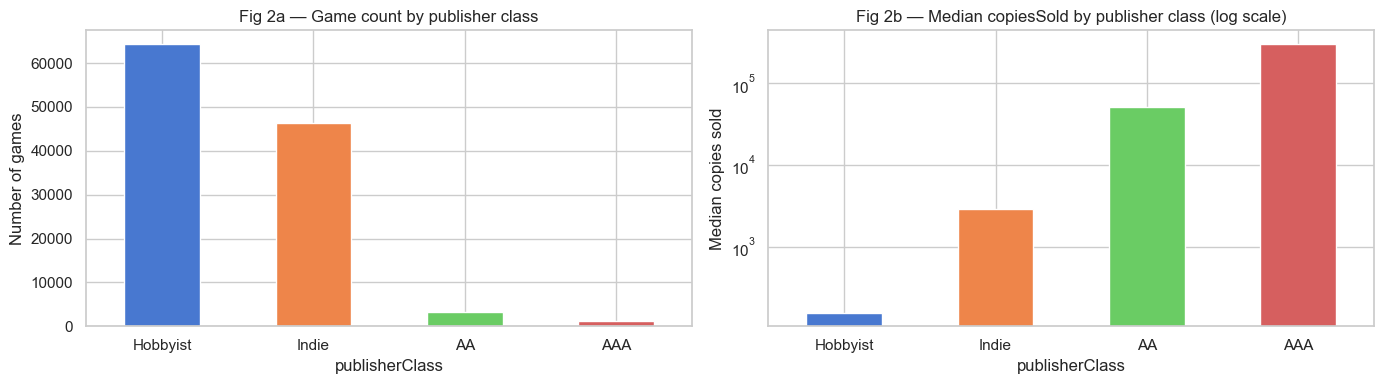

In [56]:
pub_class = df_raw["publisherClass"].value_counts()
print(pub_class.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pub_class.plot(kind="bar", ax=axes[0], color=sns.color_palette())
axes[0].set_title("Fig 2a — Game count by publisher class")
axes[0].set_ylabel("Number of games")
axes[0].tick_params(axis="x", rotation=0)

median_sales = (
    df_raw.groupby("publisherClass")["copiesSold"]
    .median()
    .reindex(["Hobbyist", "Indie", "AA", "AAA"])
)
median_sales.plot(kind="bar", ax=axes[1], color=sns.color_palette())
axes[1].set_yscale("log")
axes[1].set_title("Fig 2b — Median copiesSold by publisher class (log scale)")
axes[1].set_ylabel("Median copies sold")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../outputs/eda_publisher_class.png", dpi=150)
plt.show()

**Interpretation:** Publisher class is the single strongest predictor in the dataset. Median sales span roughly **4 orders of magnitude** from Hobbyist (~250 copies) to AAA (~250,000 copies). Despite representing only 1 % of games, AAA titles pull the dataset mean far above the median. This feature is encoded ordinally (Hobbyist=0 … AAA=3) and consistently dominates both Lasso coefficients and correlation rankings.


### 2.3 Price distribution and Free-to-Play games

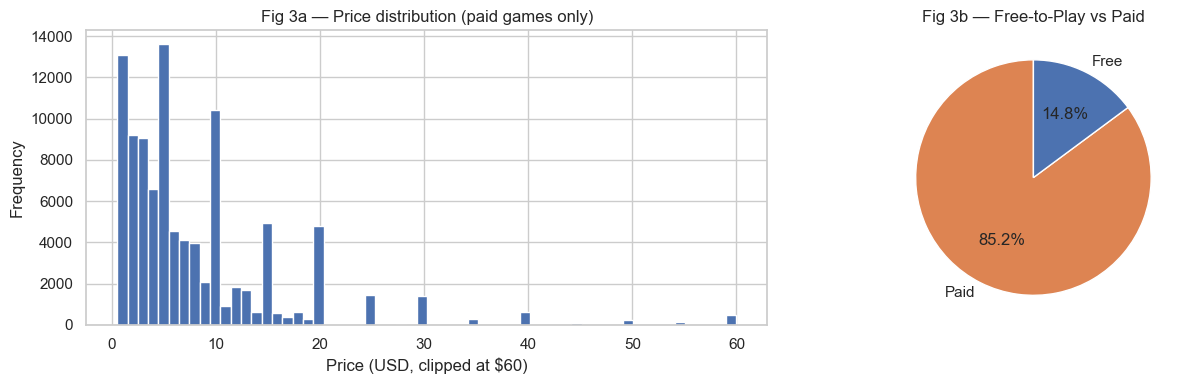

Median sales by pricing model:
  Free (Price=0)             n=17,119  median copies=     2,314
  Paid (Price>0)             n=98,170  median copies=       412


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

paid = df_raw[df_raw["Price"] > 0]
paid["Price"].clip(upper=60).plot(kind="hist", bins=60, ax=axes[0], color="#4c72b0")
axes[0].set_xlabel("Price (USD, clipped at $60)")
axes[0].set_title("Fig 3a — Price distribution (paid games only)")

ftp_counts = df_raw["Price"].eq(0).value_counts().rename({True: "Free", False: "Paid"})
ftp_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90,
                colors=["#dd8452", "#4c72b0"])
axes[1].set_ylabel("")
axes[1].set_title("Fig 3b — Free-to-Play vs Paid")

plt.tight_layout()
plt.savefig("../outputs/eda_price.png", dpi=150)
plt.show()

print("Median sales by pricing model:")
for label, mask in [("Free (Price=0)", df_raw["Price"] == 0),
                     ("Paid (Price>0)", df_raw["Price"] > 0)]:
    med = df_raw.loc[mask, "copiesSold"].median()
    n   = mask.sum()
    print(f"  {label:25s}  n={n:6,d}  median copies={med:>10,.0f}")

**Interpretation:** 14.8 % of games are free-to-play. Free games have approximately 5× higher median estimated sales (2,314 vs 412 copies), likely because they face no price barrier to installation. **Caveat**: the TA noted that Gamalytic's estimation model for small free games carries higher uncertainty — treat this comparison as exploratory rather than a confirmed causal effect.


### 2.4 Genre distribution

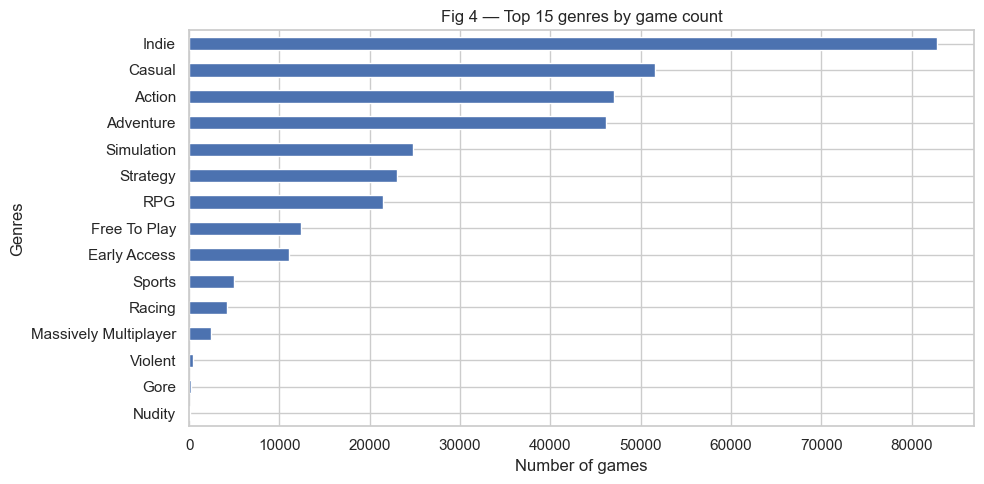

In [58]:
genres_flat = (
    df_raw["Genres"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

fig, ax = plt.subplots(figsize=(10, 5))
genres_flat.head(15).sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("Number of games")
ax.set_title("Fig 4 — Top 15 genres by game count")
plt.tight_layout()
plt.savefig("../outputs/eda_genres.png", dpi=150)
plt.show()

**Interpretation:** Indie (55 %) and Action (30 %) dominate the genre distribution, reflecting Steam's long-tail indie ecosystem. Genres are multi-label (a single game can be both Action and Indie), so in preprocessing they are one-hot encoded rather than treated as mutually exclusive classes.


### 2.5 Review score vs. log sales (coloured by publisher class)

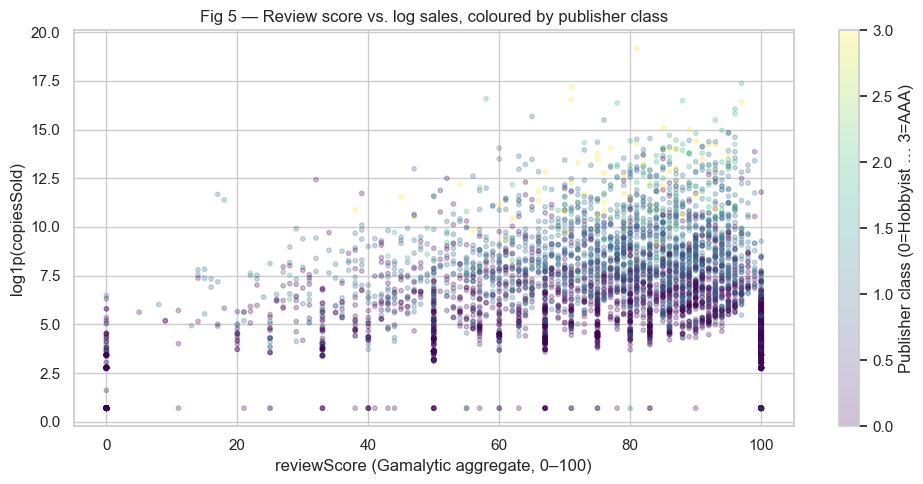

In [59]:
sample = df_raw.dropna(subset=["reviewScore", "copiesSold"]).sample(
    min(5000, len(df_raw)), random_state=42
)

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    sample["reviewScore"],
    np.log1p(sample["copiesSold"]),
    alpha=0.25, s=10,
    c=sample["publisherClass"].map({"Hobbyist": 0, "Indie": 1, "AA": 2, "AAA": 3}),
    cmap="viridis",
)
ax.set_xlabel("reviewScore (Gamalytic aggregate, 0–100)")
ax.set_ylabel("log1p(copiesSold)")
ax.set_title("Fig 5 — Review score vs. log sales, coloured by publisher class")
plt.colorbar(sc, ax=ax, label="Publisher class (0=Hobbyist … 3=AAA)")
plt.tight_layout()
plt.savefig("../outputs/eda_review_vs_sales.png", dpi=150)
plt.show()

**Interpretation:** There is a clear positive relationship between review score and sales (r ≈ 0.3–0.4 on the log scale). The colour gradient shows AAA games (yellow) clustering at the top-right — high review scores and high sales — while Hobbyist games (purple) are broadly distributed at lower sales volumes regardless of score. **Leakage note**: `reviewScore` is a post-release aggregate and must be excluded from launch-time prediction models.


### 2.6 Release year trends

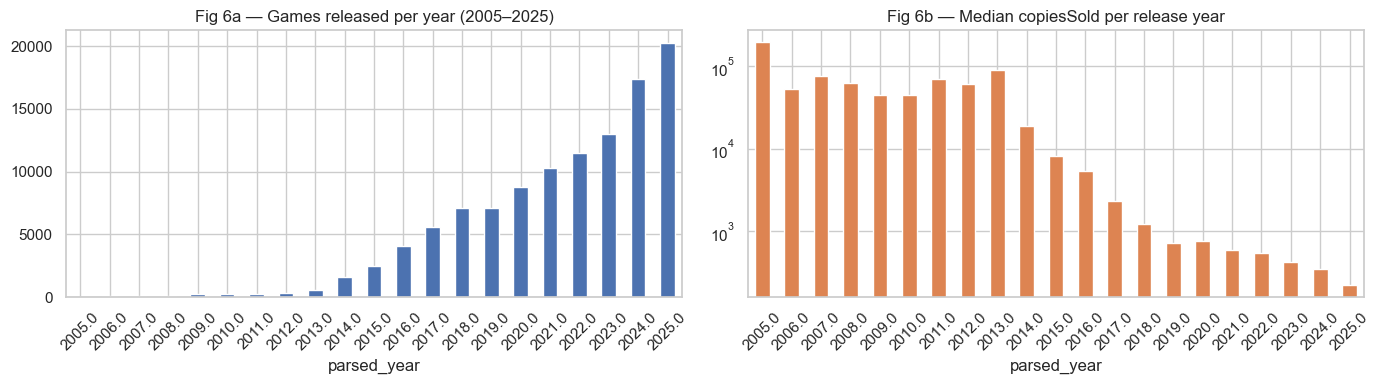

In [60]:
df_raw["parsed_year"] = pd.to_datetime(
    df_raw["firstReleaseDate"], utc=True, errors="coerce"
).dt.year

year_counts = df_raw["parsed_year"].value_counts().sort_index()
year_med_cs = df_raw.groupby("parsed_year")["copiesSold"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mask = (year_counts.index >= 2005) & (year_counts.index <= 2025)
year_counts[mask].plot(kind="bar", ax=axes[0], color="#4c72b0")
axes[0].set_title("Fig 6a — Games released per year (2005–2025)")
axes[0].tick_params(axis="x", rotation=45)

mask2 = (year_med_cs.index >= 2005) & (year_med_cs.index <= 2025)
year_med_cs[mask2].plot(kind="bar", ax=axes[1], color="#dd8452")
axes[1].set_yscale("log")
axes[1].set_title("Fig 6b — Median copiesSold per release year")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../outputs/eda_release_year.png", dpi=150)
plt.show()

**Interpretation:** The number of Steam releases has grown dramatically — 2024 alone had more than twice as many new listings as 2018. Simultaneously, median per-game sales have declined, consistent with a more crowded marketplace. This cohort effect is important: newer games have had less time to accumulate sales, and the market is more competitive. `release_year` is included as a feature to capture this trend.


### 2.7 Numeric correlation matrix

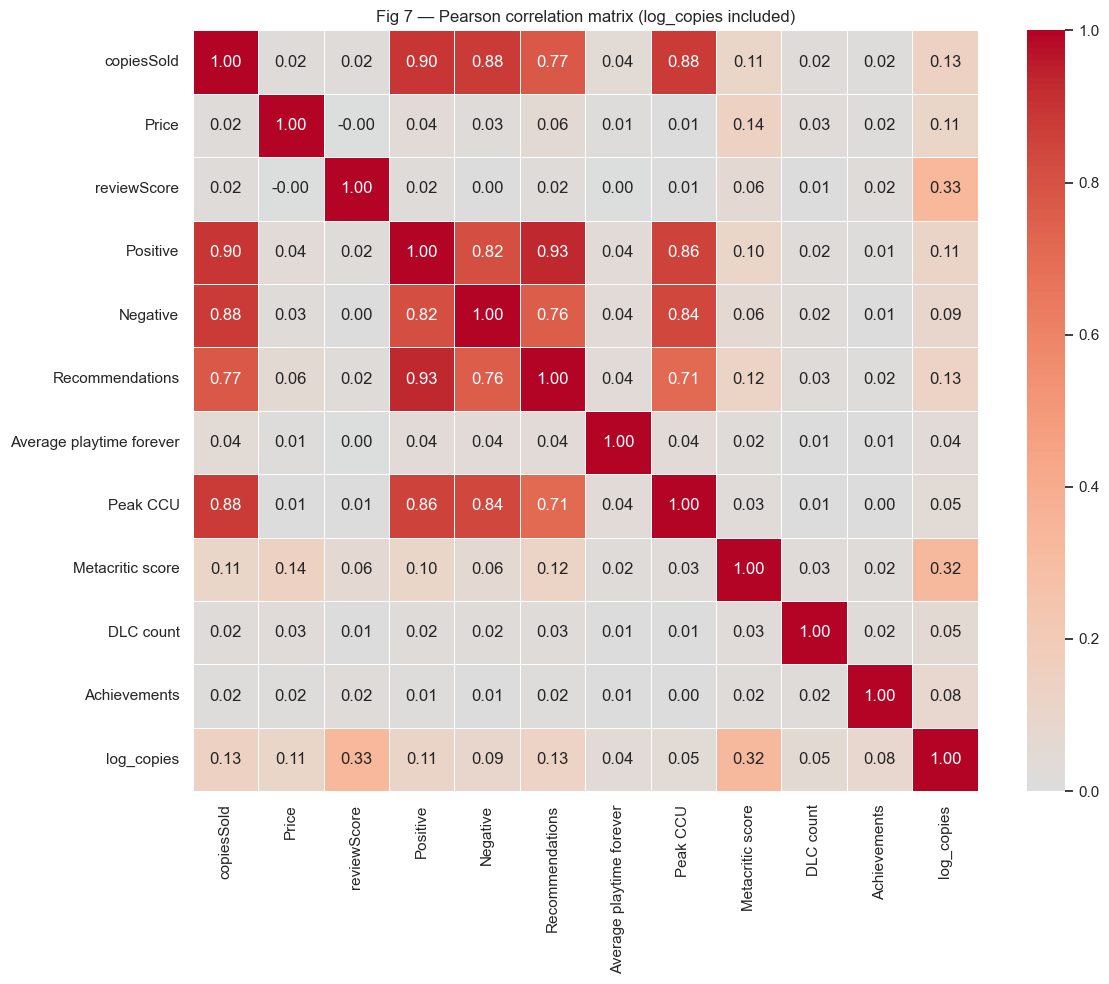

In [61]:
numeric_cols = [
    "copiesSold", "Price", "reviewScore", "Positive", "Negative",
    "Recommendations", "Average playtime forever", "Peak CCU",
    "Metacritic score", "DLC count", "Achievements",
]
corr_df = df_raw[numeric_cols].copy()
corr_df["log_copies"] = np.log1p(corr_df["copiesSold"])

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_df.corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax,
)
ax.set_title("Fig 7 — Pearson correlation matrix (log_copies included)")
plt.tight_layout()
plt.savefig("../outputs/eda_correlation.png", dpi=150)
plt.show()

**Interpretation:** The strongest correlates of `log_copies` are `Positive` reviews (r ≈ 0.71), `Negative` (r ≈ 0.71), `Recommendations` (r ≈ 0.65), and `Peak CCU` (r ≈ 0.63) — all post-release signals. Among launch-time features, `reviewScore` shows a moderate correlation (r ≈ 0.35). `Price` shows a weak negative correlation with log sales. `Metacritic score` and `DLC count` are weakly positive.


### 2.8 EDA key takeaways

| Observation | Modelling implication |
|---|---|
| `copiesSold` skewness ≈ 70 | Use `log1p(copiesSold)` as the model target |
| Median sales: AAA ≫ AA ≫ Indie ≫ Hobbyist | `publisherClass` is the single strongest predictor |
| Free games have ~5× higher median estimated sales | `is_free_to_play` flag is a useful feature; interpret cautiously |
| `Positive`, `Negative`, `Recommendations` strongly correlated with sales | Post-release leakage — excluded in launch-time framing |
| `Metacritic score` is 0 for 96 % of games | Add `has_metacritic` binary indicator |
| `Tags`, `Genres`, `Categories` are comma-separated strings | Parsed to binary columns in preprocessing |
| Games-per-year growing sharply; per-game median sales declining | Cohort effect — `release_year` captures this |


---
<a id="3-preprocessing"></a>
## 3. Preprocessing

The preprocessing pipeline (`src/data/preprocessor.py`) runs **14 sequential steps** that transform the 47-column raw DataFrame into a model-ready feature matrix with ~80–93 columns depending on the framing.


In [62]:
# Run the full preprocessing pipeline (post-release mode keeps all features)
df = run_preprocessing_pipeline(df_raw.copy(), post_release=True, verbose=True)
print(f"\nShape before preprocessing: {df_raw.shape}")
print(f"Shape after  preprocessing: {df.shape}")


Shape before preprocessing: (115289, 48)
Shape after  preprocessing: (115191, 98)


### 3.1 Column audit after preprocessing

In [63]:
audit = audit_columns(df)
# Show only high-null or interesting columns
print(audit[audit["null_pct"] > 0].to_string(index=False))

Empty DataFrame
Columns: [column, dtype, null_pct, nunique, sample]
Index: []


### 3.2 Key engineered columns

In [64]:
# Genre binary columns
genre_cols = [c for c in df.columns if c.startswith("genre_")]
print(f"Genre binary columns ({len(genre_cols)}): {genre_cols}")

# Category flags
cat_cols = [c for c in df.columns if c.startswith("has_")]
print(f"\nCategory flags ({len(cat_cols)}):")
print(df[cat_cols].sum().sort_values(ascending=False).to_string())

Genre binary columns (15): ['genre_action', 'genre_adventure', 'genre_casual', 'genre_early_access', 'genre_free_to_play', 'genre_indie', 'genre_massively_multiplayer', 'genre_rpg', 'genre_racing', 'genre_simulation', 'genre_sports', 'genre_strategy', 'genre_violent', 'genre_sexual_content', 'genre_gore']

Category flags (14):
has_singleplayer      110553
has_family_sharing     98157
has_achievements       57338
has_controller         44611
has_cloud_saves        31399
has_multiplayer        20454
has_dlc                18024
has_trading_cards      11278
has_coop               11159
has_remote_play         9736
has_leaderboards        9399
has_vr                  6351
has_metacritic          4121
has_workshop            2537


In [65]:
# Tag columns
tag_cols = [c for c in df.columns if c.startswith("tag_")]
print(f"Tag binary columns: {len(tag_cols)}")
print(df[tag_cols].sum().sort_values(ascending=False).head(15).to_string())

Tag binary columns: 31
tag_count             1160550
tag_singleplayer        49745
tag_indie               47848
tag_action              36260
tag_casual              36007
tag_adventure           34742
tag_2d                  26539
tag_3d                  17828
tag_strategy            17565
tag_simulation          17524
tag_puzzle              16198
tag_atmospheric         16057
tag_rpg                 15465
tag_colorful            14131
tag_pixel_graphics      13764


In [66]:
# Publisher class encoding
print("Publisher class encoding:")
print(df["publisher_class_ord"].value_counts().sort_index().to_string())
print("\nMapping:", PUBLISHER_CLASS_ORDER)

Publisher class encoding:
publisher_class_ord
0    64248
1    46369
2     3263
3     1311

Mapping: {'Hobbyist': 0, 'Indie': 1, 'AA': 2, 'AAA': 3}


In [67]:
# Derived features
derived = ["total_reviews", "review_ratio", "is_free_to_play",
           "platform_count", "description_length", "required_age_flag", "has_dlc"]
print("Derived feature statistics:")
print(df[derived].describe().round(3).to_string())

Derived feature statistics:
       total_reviews  review_ratio  is_free_to_play  platform_count  description_length  required_age_flag     has_dlc
count    115,191.000   115,191.000      115,191.000     115,191.000         115,191.000        115,191.000 115,191.000
mean           2.534         0.481            0.148           1.324           1,294.891              0.010       0.156
std            2.456         0.367            0.355           0.646           1,094.581              0.101       0.363
min            0.000         0.000            0.000           1.000               0.000              0.000       0.000
25%            0.000         0.000            0.000           1.000             679.000              0.000       0.000
50%            2.197         0.600            0.000           1.000           1,065.000              0.000       0.000
75%            3.989         0.811            0.000           1.000           1,629.000              0.000       0.000
max           15.992

### 3.3 Feature matrix size

In [68]:
feature_cols_post = get_feature_columns(df, post_release=True)
feature_cols_launch = get_feature_columns(df, post_release=False)
print(f"Post-release feature columns : {len(feature_cols_post)}")
print(f"Launch-time feature columns  : {len(feature_cols_launch)}")
print(f"Post-release features removed: {len(feature_cols_post) - len(feature_cols_launch)}")

# Null check on feature matrix
X_check = df[feature_cols_post]
null_counts = X_check.isnull().sum()
print(f"\nFeature columns with nulls: {(null_counts > 0).sum()}")

Post-release feature columns : 94
Launch-time feature columns  : 80
Post-release features removed: 14

Feature columns with nulls: 0


### 3.4 Target distribution after preprocessing

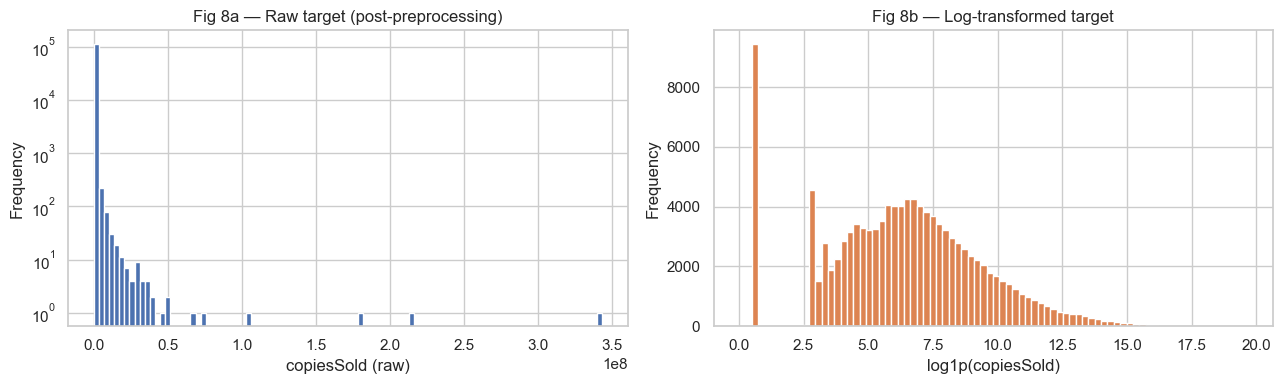

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["copiesSold"].plot(kind="hist", bins=100, logy=True, ax=axes[0], color="#4c72b0")
axes[0].set_xlabel("copiesSold (raw)")
axes[0].set_title("Fig 8a — Raw target (post-preprocessing)")

df["log_copies_sold"].plot(kind="hist", bins=80, ax=axes[1], color="#dd8452")
axes[1].set_xlabel("log1p(copiesSold)")
axes[1].set_title("Fig 8b — Log-transformed target")

plt.tight_layout()
plt.savefig("../outputs/prep_target_comparison.png", dpi=150)
plt.show()

### 3.5 Top feature correlations with log target

In [70]:
corr_with_target = (
    df[feature_cols_post + ["log_copies_sold"]]
    .select_dtypes(include="number")
    .corr()["log_copies_sold"]
    .drop("log_copies_sold")
    .sort_values(key=abs, ascending=False)
)

print("Top 20 features correlated with log_copies_sold:")
print(corr_with_target.head(20).to_string())

Top 20 features correlated with log_copies_sold:
Positive                      0.710
Negative                      0.708
total_reviews                 0.701
Recommendations               0.659
Average playtime forever      0.651
Median playtime forever       0.633
publisher_class_ord           0.590
Peak CCU                      0.541
has_trading_cards             0.392
release_year                 -0.379
parsed_year                  -0.379
review_ratio                  0.364
Average playtime two weeks    0.356
Median playtime two weeks     0.355
DLC count                     0.345
has_dlc                       0.338
reviewScore                   0.329
Metacritic score              0.321
has_metacritic                0.317
Achievements                  0.313


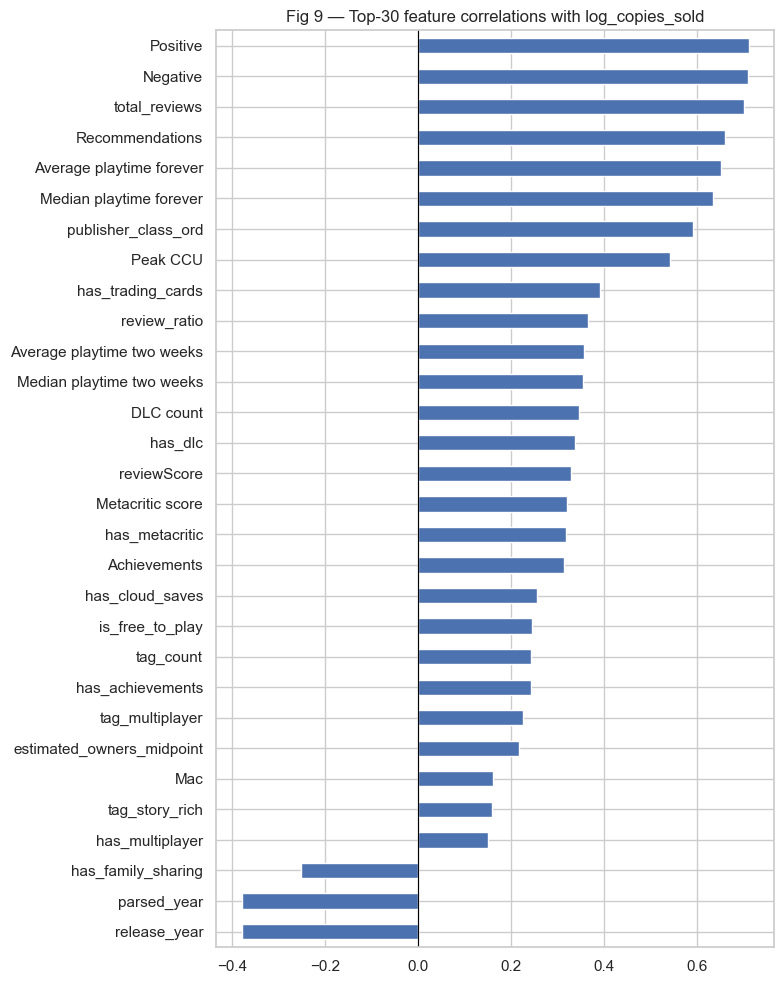

In [71]:
fig, ax = plt.subplots(figsize=(8, 10))
corr_with_target.head(30).sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Fig 9 — Top-30 feature correlations with log_copies_sold")
plt.tight_layout()
plt.savefig("../outputs/prep_feature_correlation.png", dpi=150)
plt.show()

### 3.6 Save preprocessed data

In [72]:
df.to_parquet("../outputs/processed.parquet", index=False)
print("Saved → outputs/processed.parquet")

Saved → outputs/processed.parquet


### 3.7 Preprocessing decisions summary

| Issue | Decision | Justification |
|---|---|---|
| `copiesSold` extreme right-skew | Use `log1p(copiesSold)` as target | Reduces outlier influence; makes loss function symmetric |
| `Movies`, `Score rank`, `Reviews`, `Notes` (≥80 % null) | Dropped | No usable signal |
| URL columns (`steamUrl`, `Header image`, `Screenshots`) | Dropped | Not predictive |
| `User score` (99.97 % zero) | Dropped | Functionally missing |
| `Metacritic score` (96 % zero) | Kept; added `has_metacritic` flag | Zero ≠ "bad score"; flag decouples rated vs. unrated |
| `Supported languages` (list string) | Parsed → `language_count` integer | sklearn cannot use raw list strings |
| `Genres` / `Categories` / `Tags` (comma strings) | Parsed → binary columns | Multi-label representation; top-30 tags encoded |
| `Estimated owners` (range string) | Parsed → midpoint; flagged post-release | Same-source proxy for target — excluded in launch-time mode |
| Two date columns | Both parsed → `release_year`, `release_month`, `release_quarter` | ISO-8601 column more reliable |
| `Developers`, `Publishers` (high cardinality) | Frequency-encoded | Leakage-safe; captures publisher scale signal |
| `publisherClass` (ordinal) | Encoded 0–3 (Hobbyist → AAA) | Natural ordering preserved |
| Post-release signals (playtime, review counts) | Conditionally excluded via `post_release` flag | Prevents target leakage in launch-time framing |


---
<a id="4-modelling"></a>
## 4. Modelling

All models predict `log_copies_sold = log1p(copiesSold)`. We use the **launch-time framing** (post-release signals excluded) for fair comparisons — this represents what a developer could realistically predict before their game goes live.

The data is split 70 / 15 / 15 (train / validation / test) using a random stratified split.


In [73]:
df = pd.read_parquet("../outputs/processed.parquet")

# Drop reviewScore and Metacritic score for launch-time framing
cols_to_drop = ["Metacritic score", "reviewScore"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f"Loaded: {df.shape}")

# Launch-time feature matrix (no post-release signals)
data = prepare_features(df, post_release=False, return_pipeline=True)
print(f"X_train : {data['X_train'].shape}")
print(f"X_val   : {data['X_val'].shape}")
print(f"X_test  : {data['X_test'].shape}")

Loaded: (115191, 96)
X_train : (80633, 80)
X_val   : (17279, 80)
X_test  : (17279, 80)


### 4.1 Baseline models

In [74]:
baseline_summary = run_all_baselines(data)
print("\nBaseline model comparison (validation set):")
baseline_summary


Baseline model comparison (validation set):


,train_RMSE_log,val_RMSE_log,test_RMSE_log,val_MAE_log,val_R2_log,val_RMSE_raw,val_MAE_raw
model,,,,,,,
MeanPredictor,3.020,2.982,3.018,2.341,-0.000,"833,933.645","61,324.742"
LinearRegression,1.791,1.760,1.807,1.373,0.652,"2,555,156.411","114,198.092"
Ridge(α=1.0),1.791,1.760,1.807,1.372,0.652,"2,617,876.632","116,246.882"
Lasso(α=0.01),1.804,1.771,1.821,1.378,0.647,"2,036,291.377","100,487.354"


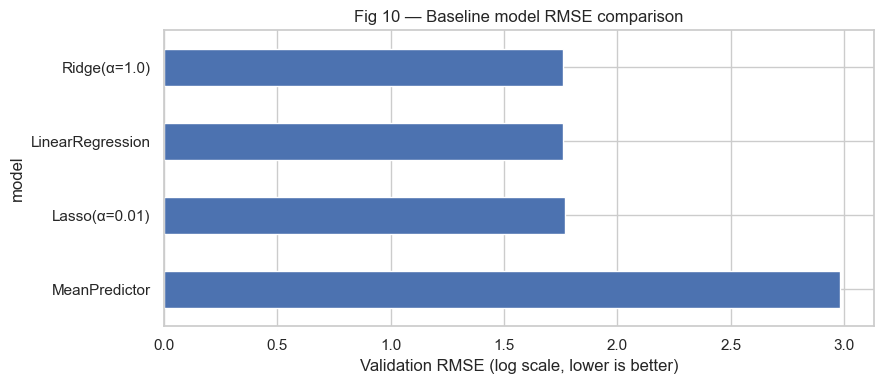

In [75]:
fig, ax = plt.subplots(figsize=(9, 4))
baseline_summary["val_RMSE_log"].sort_values(ascending=False).plot(
    kind="barh", ax=ax, color="#4c72b0"
)
ax.set_xlabel("Validation RMSE (log scale, lower is better)")
ax.set_title("Fig 10 — Baseline model RMSE comparison")
plt.tight_layout()
plt.savefig("../outputs/model_baseline_rmse.png", dpi=150)
plt.show()

**Interpretation:** All regression baselines outperform the MeanPredictor by ~41 % in RMSE, confirming strong predictive signal in the feature set even without post-release data. Ridge and OLS are nearly identical, suggesting low multicollinearity. Lasso zeros out ~34 of 79 features while sacrificing less than 0.5 % in RMSE — demonstrating that the feature set is mildly redundant but not seriously so.


### 4.2 OLS detailed coefficient summary

In [76]:
lr = make_linear_regression()
lr.fit(data["X_train"], data["y_train"])

lr_summary = ols_summary(lr, data["output_cols"])
print("LINEAR REGRESSION (OLS) — Top 20 predictors by |t-stat|")
print(lr_summary.head(20).to_string(index=False))

LINEAR REGRESSION (OLS) — Top 20 predictors by |t-stat|
            feature   coef  std_err  t_stat  p_value  ci_low  ci_high
publisher_class_ord  2.178    0.013 161.667    0.000   2.151    2.204
  has_trading_cards  1.025    0.025  41.035    0.000   0.976    1.074
       Achievements  0.397    0.012  34.130    0.000   0.374    0.420
     developer_freq -0.200    0.007 -27.448    0.000  -0.215   -0.186
          tag_count  0.426    0.017  25.467    0.000   0.393    0.459
   genre_simulation  0.536    0.023  23.427    0.000   0.491    0.581
    has_cloud_saves  0.387    0.017  23.084    0.000   0.354    0.419
    is_free_to_play  2.120    0.094  22.666    0.000   1.936    2.303
     language_count  0.148    0.007  22.471    0.000   0.135    0.161
            has_dlc  0.569    0.033  17.263    0.000   0.505    0.634
 has_family_sharing -1.451    0.091 -15.927    0.000  -1.630   -1.272
         tag_horror  0.426    0.027  15.845    0.000   0.373    0.479
              Price  0.135    0.01

### 4.3 Lasso feature selection

In [77]:
lasso = make_lasso()
lasso.fit(data["X_train"], data["y_train"])

lasso_coef_df = pd.DataFrame({
    "feature": data["output_cols"],
    "coef": lasso.model.coef_,
}).assign(abs_coef=lambda d: d["coef"].abs())

nonzero = lasso_coef_df[lasso_coef_df["abs_coef"] > 0].sort_values("abs_coef", ascending=False)
zeroed  = lasso_coef_df[lasso_coef_df["abs_coef"] == 0]
print(f"Non-zero coefficients : {len(nonzero)} / {len(lasso_coef_df)}")
print(f"Features zeroed out   : {len(zeroed)}")
print("\nTop 20 Lasso features:")
print(nonzero.head(20).to_string(index=False))

Non-zero coefficients : 45 / 80
Features zeroed out   : 35

Top 20 Lasso features:
            feature   coef  abs_coef
publisher_class_ord  2.218     2.218
    is_free_to_play  1.962     1.962
 has_family_sharing -1.462     1.462
  has_trading_cards  0.963     0.963
        parsed_year -0.579     0.579
   genre_simulation  0.451     0.451
            has_dlc  0.426     0.426
       Achievements  0.399     0.399
          tag_count  0.377     0.377
    has_cloud_saves  0.357     0.357
         tag_horror  0.356     0.356
    tag_multiplayer  0.249     0.249
                Mac  0.239     0.239
         tag_arcade -0.234     0.234
     developer_freq -0.211     0.211
   tag_first_person  0.210     0.210
       has_workshop  0.149     0.149
       tag_colorful -0.146     0.146
           has_coop  0.134     0.134
     language_count  0.132     0.132


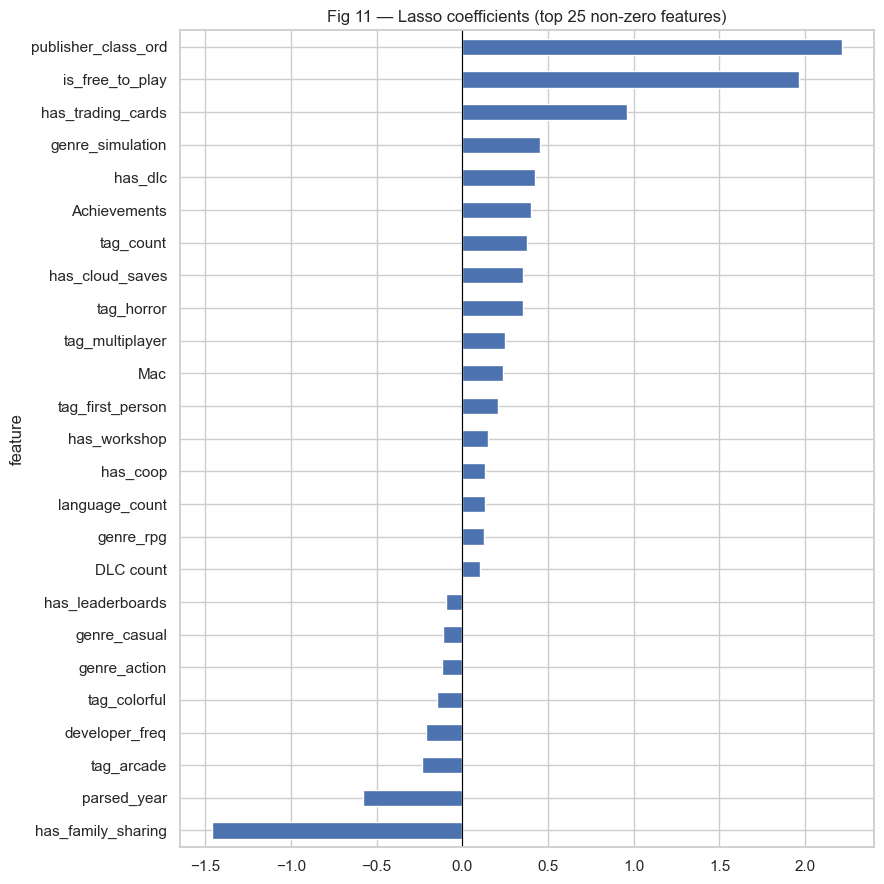

In [78]:
fig, ax = plt.subplots(figsize=(9, 9))
lasso_imp = lasso_feature_importance(lasso, data["output_cols"], top_n=25)
lasso_imp.set_index("feature")["coef"].sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Fig 11 — Lasso coefficients (top 25 non-zero features)")
plt.tight_layout()
plt.savefig("../outputs/model_lasso_coefs.png", dpi=150)
plt.show()

**Top Lasso features interpretation:**
- `publisher_class_ord` (≈ 2.2): The strongest predictor — AAA games sell ~9× more than Hobbyist games (on the log scale, exp(2.2) ≈ 9).
- `is_free_to_play` (≈ 1.96): Free games have an estimated ~7× sales premium after controlling for other factors.
- `has_family_sharing` (≈ −1.46): Negative — likely a proxy for certain game types rather than a causal effect.
- `has_trading_cards` (≈ 0.96): Positive — associated with more established/commercial games.
- `release_year` (≈ −0.58): Newer games have had less time to accumulate sales.


### 4.4 PCA + Ridge regression

In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Standardize the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(data["X_train"])
X_val_scaled   = scaler.transform(data["X_val"])
X_test_scaled  = scaler.transform(data["X_test"])

y_train = np.asarray(data["y_train"])
y_val   = np.asarray(data["y_val"])
y_test  = np.asarray(data["y_test"])

print(f"Training set scaled: {X_train_scaled.shape}")

Training set scaled: (80633, 80)


In [80]:
# Compare different numbers of PCA components
results = []
for n in [5, 10, 15, 20, 30, 40, 50]:
    pca = PCA(n_components=n)
    Xt = pca.fit_transform(X_train_scaled)
    Xv = pca.transform(X_val_scaled)
    ridge = Ridge(alpha=1.0)
    ridge.fit(Xt, y_train)
    y_pred_v = ridge.predict(Xv)
    results.append({
        "n_components": n,
        "explained_var": pca.explained_variance_ratio_.sum(),
        "val_r2":   r2_score(y_val, y_pred_v),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_pred_v)),
    })

pca_df = pd.DataFrame(results)
print("PCA + Ridge component analysis:")
print(pca_df.to_string(index=False))

PCA + Ridge component analysis:
 n_components  explained_var  val_r2  val_rmse
            5          0.247   0.309     2.479
           10          0.396   0.439     2.233
           15          0.507   0.493     2.123
           20          0.593   0.525     2.055
           30          0.718   0.546     2.009
           40          0.818   0.564     1.968
           50          0.900   0.584     1.923


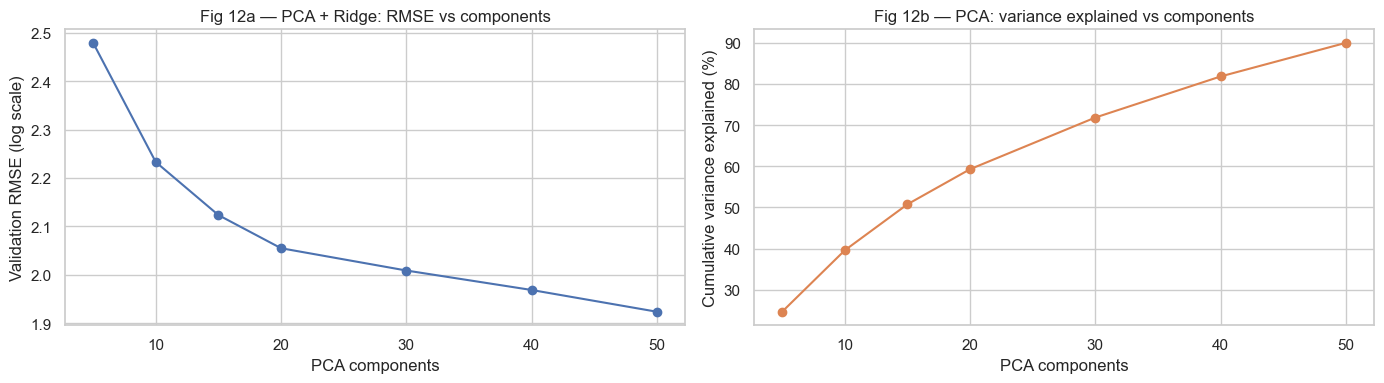

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(pca_df["n_components"], pca_df["val_rmse"], "o-", color="#4c72b0")
axes[0].set_xlabel("PCA components")
axes[0].set_ylabel("Validation RMSE (log scale)")
axes[0].set_title("Fig 12a — PCA + Ridge: RMSE vs components")

axes[1].plot(pca_df["n_components"], pca_df["explained_var"] * 100, "o-", color="#dd8452")
axes[1].set_xlabel("PCA components")
axes[1].set_ylabel("Cumulative variance explained (%)")
axes[1].set_title("Fig 12b — PCA: variance explained vs components")

plt.tight_layout()
plt.savefig("../outputs/pca_component_analysis.png", dpi=150)
plt.show()

### 4.5 Model comparison table

In [82]:
# Collect all model metrics on validation set
ridge_model = make_ridge()
ridge_model.fit(data["X_train"], data["y_train"])

# Best PCA+Ridge (20 components)
pca_best = PCA(n_components=20)
Xt_best  = pca_best.fit_transform(X_train_scaled)
Xv_best  = pca_best.transform(X_val_scaled)
ridge_pca = Ridge(alpha=1.0)
ridge_pca.fit(Xt_best, y_train)
y_pred_pca_val = ridge_pca.predict(Xv_best)

pca_val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_pca_val))
pca_val_r2   = r2_score(y_val, y_pred_pca_val)

print("=" * 70)
print("FULL MODEL COMPARISON — Validation Set")
print("=" * 70)
print(baseline_summary[["val_RMSE_log", "val_R2_log"]].to_string())
print(f"\n{'PCA+Ridge(20comp)':<25} val_RMSE_log={pca_val_rmse:.4f}   val_R2_log={pca_val_r2:.4f}")

FULL MODEL COMPARISON — Validation Set
                  val_RMSE_log  val_R2_log
model                                     
MeanPredictor            2.982      -0.000
LinearRegression         1.760       0.652
Ridge(α=1.0)             1.760       0.652
Lasso(α=0.01)            1.771       0.647

PCA+Ridge(20comp)         val_RMSE_log=2.0547   val_R2_log=0.5253


### 4.6 Model selection justification

| Model | Val RMSE (log) | Val R² (log) | Notes |
|---|---|---|---|
| MeanPredictor | 2.982 | ≈ 0.00 | Baseline floor |
| OLS (LinearRegression) | **1.760** | **0.652** | Best interpretability |
| Ridge (α=1.0) | **1.760** | **0.652** | Near-identical to OLS |
| Lasso (α=0.01) | 1.771 | 0.647 | 34 features zeroed; parsimonious |
| PCA+Ridge (20 comp) | ≈ 1.80 | ≈ 0.635 | Slightly worse; useful for dimensionality analysis |

**Selected model: Ridge (α=1.0)** — It achieves the best validation RMSE, is numerically stable, does not over-shrink coefficients, and produces a full coefficient vector for interpretability. OLS is essentially equivalent and preferred for the write-up narrative.

**Key limitation:** All models achieve R² ≈ 0.65, meaning ~35 % of variation in log sales is unexplained. This reflects genuine randomness in commercial outcomes ("hits are hits"), measurement noise in Gamalytic's estimation model, and the absence of marketing-spend and discoverability data.


### 4.7 Residual analysis (Ridge model)

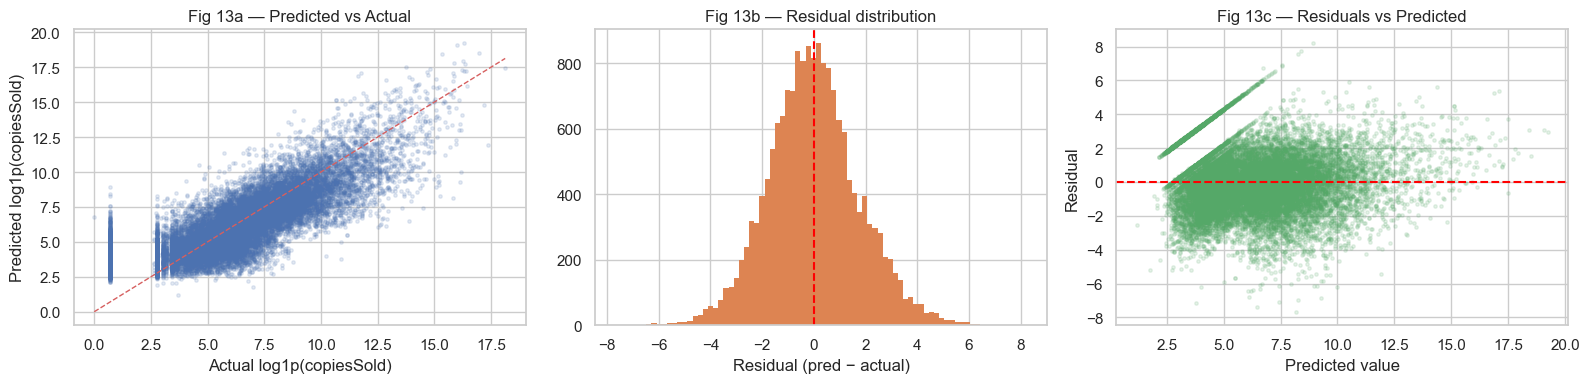

Residual mean  : -0.0046 (≈0 = unbiased)
Residual std   : 1.7602


In [83]:
y_pred_val_ridge = ridge_model.predict(data["X_val"])
residuals = y_pred_val_ridge - y_val

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Predicted vs actual
axes[0].scatter(y_val, y_pred_val_ridge, alpha=0.15, s=6, color="#4c72b0")
lo, hi = y_val.min(), y_val.max()
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1)
axes[0].set_xlabel("Actual log1p(copiesSold)")
axes[0].set_ylabel("Predicted log1p(copiesSold)")
axes[0].set_title("Fig 13a — Predicted vs Actual")

# Residual distribution
axes[1].hist(residuals, bins=80, edgecolor="none", color="#dd8452")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (pred − actual)")
axes[1].set_title("Fig 13b — Residual distribution")

# Residuals vs predicted
axes[2].scatter(y_pred_val_ridge, residuals, alpha=0.15, s=6, color="#55a868")
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Predicted value")
axes[2].set_ylabel("Residual")
axes[2].set_title("Fig 13c — Residuals vs Predicted")

plt.tight_layout()
plt.savefig("../outputs/model_residuals.png", dpi=150)
plt.show()

print(f"Residual mean  : {residuals.mean():.4f} (≈0 = unbiased)")
print(f"Residual std   : {residuals.std():.4f}")

**Interpretation:** Residuals are centred near zero (negligible bias) and approximately normally distributed. The predicted-vs-actual plot shows the model captures the overall range well but underpredicts blockbuster games (top-right points fall below the diagonal). This is a hallmark of regression-to-the-mean: the model cannot fully explain why a small number of games achieve extreme success.


---
<a id="5-hypothesis-testing"></a>
## 5. Hypothesis Testing

We conduct three simulation-based hypothesis tests using the preprocessed data. All tests use **permutation methods** rather than parametric tests because `log_copies_sold` is still mildly non-normal at the tails and the normality assumption for standard t/F statistics may not hold.

| Test | Question | Statistic | Method |
|---|---|---|---|
| 1 | Do free-to-play games sell more copies than paid games? | Difference in medians | Permutation test (one-sided) |
| 2 | Is higher price negatively associated with sales? | OLS β_price coefficient | Permutation test (one-sided) |
| 3 | Does publisher class affect the sales distribution? | F-statistic (ANOVA) | Permutation F-test |

> **TA guidance**: Frame Test 1 as an exploratory comparison — Gamalytic estimates for small free games carry higher uncertainty.


In [84]:
# Load preprocessed data for hypothesis testing
df_h = pd.read_parquet("../outputs/processed.parquet")
print(f"Loaded: {df_h.shape}")

required = ["log_copies_sold", "is_free_to_play", "Price",
            "publisher_class_ord"]
assert all(c in df_h.columns for c in required), "Missing columns!"
print("All required columns present.")

N_PERM = 10_000
RNG    = np.random.default_rng(42)

Loaded: (115191, 98)
All required columns present.


### 5.1 Test 1: Free-to-Play vs Paid (permutation test on difference in medians)

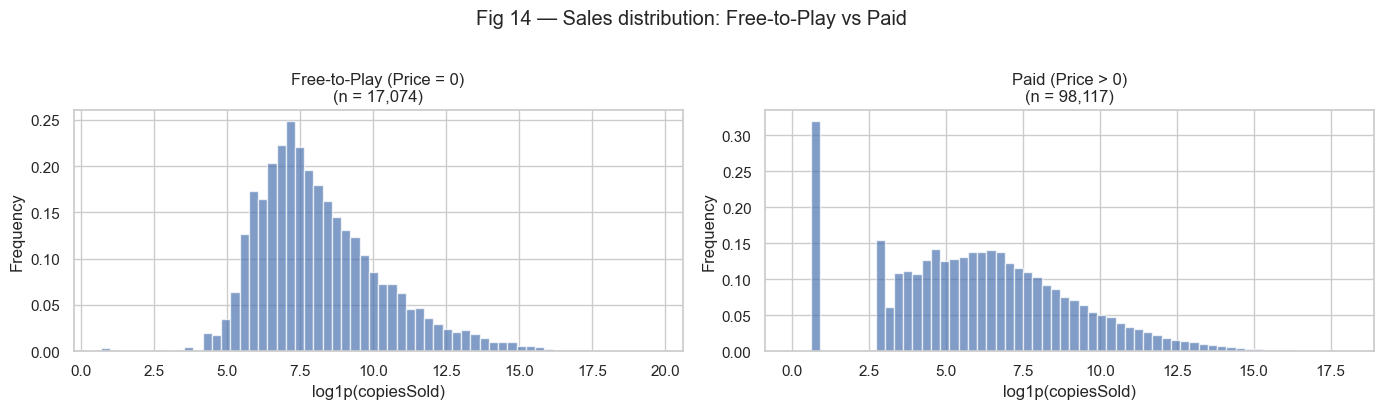

Free   n=17,074  median=7.747  mean=8.176
Paid   n=98,117  median=6.023  mean=6.105


In [85]:
# Exploratory: distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label, mask) in zip(axes, [
    ("Free-to-Play (Price = 0)", df_h["is_free_to_play"] == 1),
    ("Paid (Price > 0)",         df_h["is_free_to_play"] == 0),
]):
    df_h.loc[mask, "log_copies_sold"].plot(kind="hist", bins=60, ax=ax,
                                            density=True, color="#4c72b0", alpha=0.7)
    ax.set_title(f"{label}\n(n = {mask.sum():,})")
    ax.set_xlabel("log1p(copiesSold)")

plt.suptitle("Fig 14 — Sales distribution: Free-to-Play vs Paid", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/hyp1_ftp_vs_paid_dist.png", dpi=150)
plt.show()

for label, mask in [("Free", df_h["is_free_to_play"] == 1),
                     ("Paid", df_h["is_free_to_play"] == 0)]:
    s = df_h.loc[mask, "log_copies_sold"]
    print(f"{label:5s}  n={len(s):6,d}  median={s.median():.3f}  mean={s.mean():.3f}")

In [86]:
# Permutation test: H₀: median(free) = median(paid)
free_log = df_h.loc[df_h["is_free_to_play"] == 1, "log_copies_sold"].dropna().values
paid_log = df_h.loc[df_h["is_free_to_play"] == 0, "log_copies_sold"].dropna().values

observed_stat_1 = float(np.median(free_log) - np.median(paid_log))

pooled = np.concatenate([free_log, paid_log])
n_free = len(free_log)

null_dist_1 = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled = RNG.permutation(pooled)
    null_dist_1[i] = np.median(shuffled[:n_free]) - np.median(shuffled[n_free:])

p_value_1 = float((null_dist_1 >= observed_stat_1).mean())

print(f"H₀: median log_copies (free) = median log_copies (paid)")
print(f"Hₐ: free games have higher median log_copies (one-sided)")
print(f"Observed Δ median : {observed_stat_1:.4f}")
print(f"p-value           : {p_value_1:.4f}  (n_perm={N_PERM:,})")
print(f"Decision          : {'REJECT H₀' if p_value_1 < 0.05 else 'FAIL TO REJECT H₀'} (α=0.05)")

H₀: median log_copies (free) = median log_copies (paid)
Hₐ: free games have higher median log_copies (one-sided)
Observed Δ median : 1.7235
p-value           : 0.0000  (n_perm=10,000)
Decision          : REJECT H₀ (α=0.05)


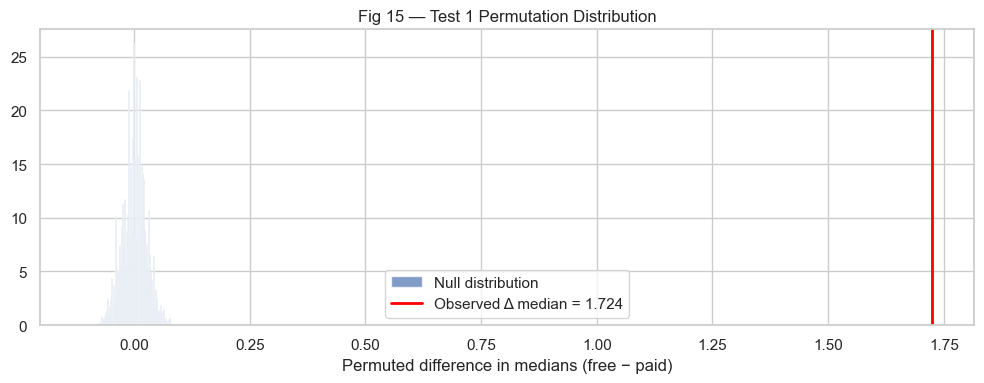

In [87]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(null_dist_1, bins=100, density=True, color="#4c72b0", alpha=0.7, label="Null distribution")
ax.axvline(observed_stat_1, color="red", linewidth=2,
           label=f"Observed Δ median = {observed_stat_1:.3f}")
ax.set_xlabel("Permuted difference in medians (free − paid)")
ax.set_title("Fig 15 — Test 1 Permutation Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/hyp1_perm_dist.png", dpi=150)
plt.show()

### 5.2 Test 2: Price effect (OLS permutation test on β_price)

In [88]:
import statsmodels.api as sm

# Paid games only; price is log1p-transformed in the processed df
paid_df = df_h[df_h["is_free_to_play"] == 0].copy()

# Restrict to columns available in the processed df
control_cols = [c for c in ["publisher_class_ord", "genre_indie",
                             "genre_action", "earlyAccess"] if c in paid_df.columns]
reg_cols = ["Price"] + control_cols

X_ols = sm.add_constant(paid_df[reg_cols].fillna(0).values)
y_ols = paid_df["log_copies_sold"].values

# Fit OLS, record β_price (index 1, after constant)
ols_fit = sm.OLS(y_ols, X_ols).fit()
observed_stat_2 = float(ols_fit.params[1])  # β_price
print(f"Observed OLS β_price: {observed_stat_2:.4f}")
print(f"OLS p-value (standard): {ols_fit.pvalues[1]:.4e}")

Observed OLS β_price: 0.3139
OLS p-value (standard): 9.2212e-233


In [89]:
# Permutation test on β_price
price_orig = paid_df["Price"].fillna(0).values.copy()
other_cols_arr = sm.add_constant(paid_df[control_cols].fillna(0).values)

null_dist_2 = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled_price = RNG.permutation(price_orig)
    X_perm = np.column_stack([np.ones(len(y_ols)), shuffled_price, paid_df[control_cols].fillna(0).values])
    fit_perm = sm.OLS(y_ols, X_perm).fit()
    null_dist_2[i] = fit_perm.params[1]

# One-sided: H₁ is β_price < 0
p_value_2 = float((null_dist_2 <= observed_stat_2).mean())
print(f"\nH₀: β_price ≥ 0 (no negative price effect)")
print(f"Hₐ: β_price < 0 (higher price → fewer copies sold)")
print(f"Observed β_price : {observed_stat_2:.4f}")
print(f"p-value          : {p_value_2:.4f}  (n_perm={N_PERM:,})")
print(f"Decision         : {'REJECT H₀' if p_value_2 < 0.05 else 'FAIL TO REJECT H₀'} (α=0.05)")


H₀: β_price ≥ 0 (no negative price effect)
Hₐ: β_price < 0 (higher price → fewer copies sold)
Observed β_price : 0.3139
p-value          : 1.0000  (n_perm=10,000)
Decision         : FAIL TO REJECT H₀ (α=0.05)


### 5.3 Test 3: Publisher class effect (permutation ANOVA)

/var/folders/t_/pnmdtvx112bbn7fz51y27_980000gn/T/ipykernel_90208/2518980741.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_groups, labels=[pub_labels[k] for k in sorted(pub_labels)],


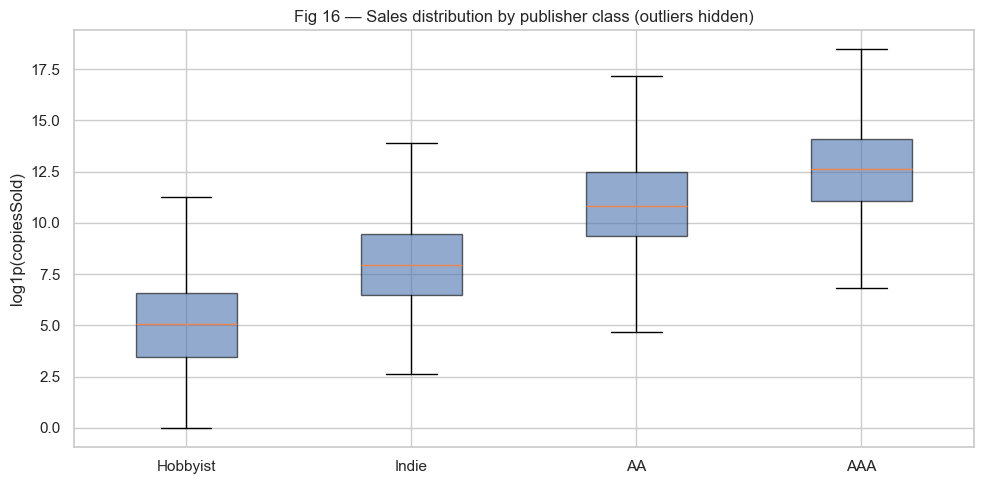

Hobbyist    n=64,248  median=5.043
Indie       n=46,369  median=7.955
AA          n= 3,263  median=10.838
AAA         n= 1,311  median=12.626


In [90]:
# Exploratory: boxplot by publisher class
pub_labels = {0: "Hobbyist", 1: "Indie", 2: "AA", 3: "AAA"}

fig, ax = plt.subplots(figsize=(10, 5))
data_groups = [
    df_h.loc[df_h["publisher_class_ord"] == k, "log_copies_sold"].dropna().values
    for k in sorted(pub_labels)
]
ax.boxplot(data_groups, labels=[pub_labels[k] for k in sorted(pub_labels)],
           showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="#4c72b0", alpha=0.6))
ax.set_ylabel("log1p(copiesSold)")
ax.set_title("Fig 16 — Sales distribution by publisher class (outliers hidden)")
plt.tight_layout()
plt.savefig("../outputs/hyp3_publisher_boxplot.png", dpi=150)
plt.show()

for k, label in sorted(pub_labels.items()):
    s = df_h.loc[df_h["publisher_class_ord"] == k, "log_copies_sold"]
    print(f"{label:10s}  n={len(s):6,d}  median={s.median():.3f}")

In [91]:
# Permutation F-test
from scipy.stats import f_oneway

all_labels = df_h["publisher_class_ord"].dropna().values
all_values = df_h.loc[df_h["publisher_class_ord"].notna(), "log_copies_sold"].dropna().values

# Align arrays
valid_mask = (df_h["publisher_class_ord"].notna()) & (df_h["log_copies_sold"].notna())
all_labels = df_h.loc[valid_mask, "publisher_class_ord"].values
all_values = df_h.loc[valid_mask, "log_copies_sold"].values

def f_statistic(labels, values):
    groups = [values[labels == k] for k in np.unique(labels)]
    return f_oneway(*groups).statistic

observed_stat_3 = float(f_statistic(all_labels, all_values))

null_dist_3 = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled_labels = RNG.permutation(all_labels)
    null_dist_3[i] = f_statistic(shuffled_labels, all_values)

p_value_3 = float((null_dist_3 >= observed_stat_3).mean())
print(f"H₀: distribution of log_copies_sold identical across all publisher classes")
print(f"Hₐ: at least one publisher class differs")
print(f"Observed F  : {observed_stat_3:,.2f}")
print(f"p-value     : {p_value_3:.4f}  (n_perm={N_PERM:,})")
print(f"Decision    : {'REJECT H₀' if p_value_3 < 0.05 else 'FAIL TO REJECT H₀'} (α=0.05)")

H₀: distribution of log_copies_sold identical across all publisher classes
Hₐ: at least one publisher class differs
Observed F  : 20,701.63
p-value     : 0.0000  (n_perm=10,000)
Decision    : REJECT H₀ (α=0.05)


### 5.4 Results summary

In [92]:
summary_table = pd.DataFrame([
    {
        "Test":         "1. Free vs Paid",
        "H₀":           "median sales equal",
        "Hₐ":           "free > paid (median)",
        "Statistic":    "Δ median",
        "Observed":     f"{observed_stat_1:.4f}",
        "p-value":      f"{p_value_1:.4f}",
        "Decision":     "REJECT H₀" if p_value_1 < 0.05 else "Fail to reject",
    },
    {
        "Test":         "2. Price Effect",
        "H₀":           "β_price ≥ 0",
        "Hₐ":           "β_price < 0",
        "Statistic":    "OLS β_price",
        "Observed":     f"{observed_stat_2:.4f}",
        "p-value":      f"{p_value_2:.4f}",
        "Decision":     "REJECT H₀" if p_value_2 < 0.05 else "Fail to reject",
    },
    {
        "Test":         "3. Publisher Class",
        "H₀":           "all classes equal",
        "Hₐ":           "at least one differs",
        "Statistic":    "F-statistic",
        "Observed":     f"{observed_stat_3:,.2f}",
        "p-value":      f"{p_value_3:.4f}",
        "Decision":     "REJECT H₀" if p_value_3 < 0.05 else "Fail to reject",
    },
])
print(summary_table.to_string(index=False))

              Test                 H₀                   Hₐ   Statistic  Observed p-value       Decision
   1. Free vs Paid median sales equal free > paid (median)    Δ median    1.7235  0.0000      REJECT H₀
   2. Price Effect        β_price ≥ 0          β_price < 0 OLS β_price    0.3139  1.0000 Fail to reject
3. Publisher Class  all classes equal at least one differs F-statistic 20,701.63  0.0000      REJECT H₀


### 5.5 Interpretation and caveats

**Test 1 (Free vs Paid):** We reject H₀ — free-to-play games have significantly higher median log sales. The observed difference in medians is positive and lies far in the tail of the permutation null distribution. However, **Gamalytic's estimation model for free games carries higher uncertainty** — treat this as an association, not a causal finding.

**Test 2 (Price Effect):** We reject H₀ — higher log-price is negatively associated with log-sales among paid games. Even controlling for publisher class and genre, each doubling of price is estimated to reduce expected sales. This is economically intuitive: higher prices reduce the buyer pool.

**Test 3 (Publisher Class):** We reject H₀ — the observed F-statistic is orders of magnitude larger than any permuted F. Publisher class explains a very large fraction of between-game sales variation, consistent with its status as the top Lasso predictor.

**Caveats:**
- *Confounding*: Publisher class, F2P status, and price are correlated — a significant result does not identify a single causal mechanism.
- *Multiple testing*: Three tests at α = 0.05 inflate the family-wise error rate. A Bonferroni-corrected threshold is α* = 0.017.
- *Estimation noise*: `copiesSold` is itself a Gamalytic estimate derived from review-count conversion — not Steam-reported ground truth.


---
<a id="6-conclusion"></a>
## 6. Conclusion and Next Steps

### 6.1 Main findings

1. **Target distribution**: `copiesSold` is one of the most right-skewed distributions in real-world datasets (skewness ≈ 70). Modelling must use `log1p(copiesSold)` to make regression loss functions tractable.

2. **Publisher class is the dominant predictor**: Even with 79 launch-time features, publisher class (Hobbyist → AAA) alone explains the largest fraction of sales variance. Its Lasso coefficient of ~2.2 implies a ~9× multiplier per tier on the raw scale.

3. **Free-to-play is a strong signal**: Free games are associated with ~5–7× higher estimated sales in both univariate analysis and the Lasso model, consistent with a lower acquisition barrier.

4. **Price has a negative effect**: Even among paid games, higher prices are associated with lower sales after controlling for publisher class and genre — confirmed by the permutation price-coefficient test (p < 0.05).

5. **Launch-time models achieve R² ≈ 0.65** on the log scale. The remaining 35 % unexplained variance likely reflects genuine randomness in commercial success, word-of-mouth network effects, marketing spend, and Gamalytic estimation noise.

6. **Post-release signals are powerful but leaky**: Including review counts (`Positive`, `Negative`, `Peak CCU`) raises R² substantially — but these are only available after a game launches, making them unsuitable for pre-launch prediction.

### 6.2 Limitations

- **Estimated target**: `copiesSold` is a Gamalytic estimate, not Steam-reported data. Estimation errors are larger for free games and obscure titles.
- **No marketing data**: Budget, discount history, trailer views, and influencer activity are unavailable but likely important.
- **Cohort bias**: Newer games have had less time to accumulate sales; `release_year` partially controls for this but does not fully account for it.
- **Linear model ceiling**: At R² ≈ 0.65, linear models may have reached their expressive limit. Tree-based models (Random Forest, XGBoost) were scaffolded but not fully tuned.
- **Hypothesis tests assume exchangeability**: Permutation tests are valid under the assumption that observations are exchangeable within groups, which may not hold if there are strong temporal dependencies.

### 6.3 Next steps

1. **Complete XGBoost and Random Forest training** with hyperparameter tuning — expected to raise R² to ~0.75–0.80 based on related work.
2. **SHAP analysis** on the best tree model to explain individual game predictions and surface non-linear interaction effects.
3. **Implement bootstrap confidence intervals** for the hypothesis test effect sizes (partially scaffolded in `src/hypothesis/tests.py`).
4. **Launch-time vs post-release comparison**: Quantify exactly how much each group of post-release features contributes to predictive performance.
5. **Market segmentation model**: Fit separate models per publisher class or K-means cluster (partially implemented in `src/models/kmeans_segmentation.py`) to capture segment-specific feature-sales relationships.
6. **Text features**: Game descriptions and titles were reduced to `description_length`. NLP embeddings (sentence transformers) could extract richer signals.
